In [32]:
import os
import sys
import re
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from scipy.stats import pearsonr
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames
from dashsrc.plot_components.plots import plot_TrackFiringRate
from dashsrc.plot_components.plots import plot_unit_fr_stability


In [33]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [1,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min']

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-04-17 15:40:08,874|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-04-17 15:40:08,874|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-04-17 15:40:08,874|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-04-17 15:40:08,883|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
2026-04-17 15:40:08,883|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
2026-04-17 15:40:08,883|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
2026-04-17 15:40:08,892|DEBUG|1682988|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 202

In [34]:
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
# fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
# behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
# behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

2026-04-17 15:40:08,939|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-04-17 15:40:08,939|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-04-17 15:40:08,939|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-04-17 15:40:08,953|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-04-17 15:40:08,953|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-04-17 15:40:08,953|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None

In [35]:
ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
#ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
# ensamble_proj.set_index(['session_id'], inplace = True)
ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-04-17 15:41:09,384|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-04-17 15:41:09,396|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-04-17 15:41:09,400|DEBUG|1682988|analytics|get_analytics
	Processing ConcatenatedEnsambles40ms, for n=31 sessions
Processing ConcatenatedEnsambles40ms, for n=31 sessions

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambles40ms.parquet
/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


2026-04-17 15:41:09,697|INFO|1682988|analytics|get_analytics
	Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475
Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475================================================================================

Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475================================================================================



In [36]:
neurons_ordered = abs(ensambles['Assembly023']).sort_values(ascending=True).index

fr_track_selected = fr_track[(fr_track['from_position_bin'] >= (-95)) & (fr_track['from_position_bin'] <= 10)] # cue zone
fr_track_selected = fr_track_selected[fr_track_selected['cue'] == 1] # cue
fr_track_selected = fr_track_selected[fr_track_selected['choice_R2'] == False] # outcome

session_ids_all = fr_track_selected.index.get_level_values("session_id").unique()
session_ids_all = pd.to_datetime(session_ids_all, format="%Y-%m-%d_%H-%M")

In [37]:
def mean_offdiag_corr(corr_df: pd.DataFrame) -> float:
    k = corr_df.shape[0]
    if k < 2:
        return np.nan
    iu = np.triu_indices(k, k=1)
    vals = corr_df.to_numpy()[iu]
    return float(np.nanmean(vals))


In [ ]:
top_ns = [10, 20, 77]
session_ids_all = fr_track_selected.index.get_level_values("session_id").unique()
fr_used = fr_z_all_sess.copy()

# 2x2 layout: correlations on first row, firing rates on second row
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Pearson corr (unweighted)", "Pearson corr (weighted)",
        "Mean firing rate (unweighted)", "Mean firing rate (weighted)"
    ),
    shared_yaxes=False,
)

weights = ensambles["Assembly023"]
weights.index = [f"Unit{int(i)+1:04d}" for i in weights.index]  # align to FR column naming


# pearson correlations for single neurons weighted and unweightes
for top_n in top_ns:
    top_n_neurons = neurons_ordered[-top_n:]
    rows_unw, rows_w = [], []

    for session_id in session_ids_all:
        neuron_data_session = fr_used.xs(session_id, level=2)

        unit_cols = [
            c for c in neuron_data_session.columns
            if isinstance(c, str) and c.startswith("Unit")
        ]
        neuron_data_session = neuron_data_session[unit_cols]

        top_unit_cols = [
            f"Unit{i+1:04d}" for i in top_n_neurons
            if f"Unit{i+1:04d}" in neuron_data_session.columns
        ]

        neuron_data_top = neuron_data_session[top_unit_cols]

        corr_unw = neuron_data_top.corr(method="pearson")
        rows_unw.append((session_id, mean_offdiag_corr(corr_unw)))

        w = weights.loc[top_unit_cols]
        neuron_data_top_w = neuron_data_top.mul(w, axis=1)
        corr_w = neuron_data_top_w.corr(method="pearson")
        rows_w.append((session_id, mean_offdiag_corr(corr_w)))

    df_unw = pd.DataFrame(rows_unw, columns=["session_id", "avg_corr"])
    df_w = pd.DataFrame(rows_w, columns=["session_id", "avg_corr"])

    fig.add_trace(
        go.Scatter(
            x=df_unw["session_id"],
            y=df_unw["avg_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
            legendgroup=f"top{top_n}",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=df_w["session_id"],
            y=df_w["avg_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
            legendgroup=f"top{top_n}",
            showlegend=False,  # avoid duplicated legend entries
        ),
        row=1,
        col=2,
    )


# mean fr
fr_units = fr_used.loc[:, fr_used.columns.str.startswith("Unit")]
# fr_units = fr.loc[:, fr.columns.str.startswith("Unit")]
fr_units = fr_units[fr_units.index.get_level_values(2) != 10]

w_all = ensambles["Assembly023"].copy()
w_all = w_all.reindex(fr_units.columns)
fr_units_weighted = fr_units.mul(w_all, axis=1)

session_means_unweighted = (
    fr_units
    .groupby(level=2)
    .mean()
    .mean(axis=1)
)

session_means_weighted = (
    fr_units_weighted
    .groupby(level=2)
    .mean()
    .mean(axis=1)
)

fig.add_scatter(
    x=session_means_unweighted.index,
    y=session_means_unweighted.values,
    mode="lines+markers",
    name="Mean FR unweighted",
    row=2,
    col=1,
)

fig.add_scatter(
    x=session_means_weighted.index,
    y=session_means_weighted.values,
    mode="lines+markers",
    name="Mean FR weighted",
    row=2,
    col=2,
)


fig.update_layout(
    title="Session-wise Pearson correlations (top row) and mean firing rates (bottom row)",
    width=1200,
    height=800,
)

fig.update_xaxes(title_text="Session", row=1, col=1)
fig.update_xaxes(title_text="Session", row=1, col=2)
fig.update_xaxes(title_text="Session", row=2, col=1)
fig.update_xaxes(title_text="Session", row=2, col=2)

fig.update_yaxes(title_text="Avg pairwise Pearson r", row=1, col=1)
fig.update_yaxes(title_text="Avg pairwise Pearson r", row=1, col=2)
fig.update_yaxes(title_text="Mean firing rate (z-scored)", row=2, col=1)
fig.update_yaxes(title_text="Mean firing rate (z-scored)", row=2, col=2)

fig.update_yaxes(range=[-1, 1], row=1, col=1)
fig.update_yaxes(range=[-1, 1], row=1, col=2)

fig.show()

In [39]:
sessions = [16, ]
assembly_name = "Assembly023"
target = "rms_a"                 # "var_a" 
min_T = 200                      # minimum time bins after filtering
min_finite_frac_per_unit = 0.99  # keep units that are finite in >=99% of rows for that session
min_units = 10
renorm_weights = True

# inputs
# selecting only sessions 14 - 18


Z_df = fr_z_all_sess.copy()#.loc[fr.index.get_level_values("session_id").isin(sessions)]
unit_cols = [c for c in Z_df.columns if isinstance(c, str) and c.startswith("Unit")]
if not unit_cols:
    raise ValueError("No 'UnitXXXX' columns found in fr_z_scored.")

w_raw = ensambles[assembly_name].copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_raw.index):
    try:
        w_raw.index = [f"Unit{int(i)+1:04d}" for i in w_raw.index]
    except Exception as e:
        raise ValueError("Could not map weight index to UnitXXXX.") from e

# Use only units present in data
units_all = [u for u in w_raw.index if u in unit_cols]
if len(units_all) < 2:
    raise ValueError("Too few overlapping units between weights and fr_z_scored.")

Z_units = Z_df[units_all]

def iter_sessions(Z: pd.DataFrame):
    if isinstance(Z.index, pd.MultiIndex) and "session_id" in Z.index.names:
        for s in sorted(Z.index.get_level_values("session_id").unique()):
            yield s, Z.xs(s, level="session_id")
        return
    if Z.index.name == "session_id":
        for s in sorted(Z.index.unique()):
            yield s, Z.loc[s]
        return
    if "session_id" in Z.columns:
        for s, g in Z.groupby("session_id", sort=True):
            yield s, g.drop(columns=["session_id"])
        return


# Per-session computation with column-wise filtering

rows = []
Sigma_by_session = {}
units_by_session = {}
w_by_session = {}

for s, Z_s in iter_sessions(Z_units):
    X = np.asarray(Z_s.values, dtype=float)  # shape (T, N_all)
    T_raw, N_all = X.shape

    if T_raw == 0:
        rows.append({"session_id": s, "T_raw": 0, "T_used": 0, "N_used": 0,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # keep units that are finite in most rows (per-session)
    finite_mask = np.isfinite(X)  # (T, N_all)
    finite_frac = finite_mask.mean(axis=0)  # (N_all,)
    keep_cols = finite_frac >= min_finite_frac_per_unit

    if keep_cols.sum() < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": 0, "N_used": int(keep_cols.sum()),
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    kept_units = list(np.array(units_all)[keep_cols])

    # subset X and drop rows that still have any NaN/inf (rare after column filter)
    Xk = X[:, keep_cols]
    ok_rows = np.isfinite(Xk).all(axis=1)
    Xk = Xk[ok_rows, :]
    T_used, N_used = Xk.shape

    if T_used < min_T or N_used < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # align weights to kept units
    w_s = w_raw.loc[kept_units].astype(float).values

    # Optional: renormalize weights so that comparisons across sessions are not dominated by changing N_used
    if renorm_weights:
        norm = np.linalg.norm(w_s)
        if norm > 0:
            w_s = w_s / norm

    # assembly activation and covariance decomposition
    a = Xk @ w_s
    mean_a = float(np.mean(a))

    Sigma = np.cov(Xk, rowvar=False, bias=False)
    var_a = float(w_s.T @ Sigma @ w_s)
    diag_var = float(np.sum((w_s ** 2) * np.diag(Sigma)))
    offdiag_var = float(var_a - diag_var)

    rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                 "mean_a": mean_a, "var_a": var_a, "diag_var": diag_var, "offdiag_var": offdiag_var})

    Sigma_by_session[s] = Sigma
    units_by_session[s] = kept_units
    w_by_session[s] = w_s

metrics = pd.DataFrame(rows).set_index("session_id").sort_index()
metrics["rms_a"] = np.sqrt(metrics["var_a"])
metrics["diag_frac"] = metrics["diag_var"] / metrics["var_a"]
metrics["offdiag_frac"] = metrics["offdiag_var"] / metrics["var_a"]

display(metrics)

# Find largest drop safely
valid = metrics[target].dropna()
if valid.shape[0] < 2:
    raise ValueError(
        f"Not enough valid sessions for target={target}. "
        f"Valid sessions={valid.shape[0]}. "
        f"Try lowering min_T, lowering min_finite_frac_per_unit, or check why many units are NaN."
    )

delta = valid.diff().dropna()
drop_session = delta.idxmin()
prev_session = valid.index[valid.index.get_loc(drop_session) - 1]

print(f"\nLargest drop in {target}: session {prev_session} -> {drop_session} (Δ={delta.loc[drop_session]:.6g})")
print(f"Session sizes: prev(T={metrics.loc[prev_session,'T_used']}, N={metrics.loc[prev_session,'N_used']}), "
      f"drop(T={metrics.loc[drop_session,'T_used']}, N={metrics.loc[drop_session,'N_used']})")


# Attribution for that drop (only on common kept units)
U_prev = units_by_session[prev_session]
U_drop = units_by_session[drop_session]
common_units = sorted(set(U_prev).intersection(U_drop))

if len(common_units) < min_units:
    raise ValueError(
        f"Too few common units between prev and drop sessions for attribution: {len(common_units)}. "
        f"This indicates strong session-to-session changes in which units are finite."
    )

# Recompute Sigma on common units only (consistent dimensionality)
def get_X_session_common(s, common_units):
    Z_s = next(g for sid, g in iter_sessions(Z_units) if sid == s)  # session df with all units_all
    X = Z_s[common_units].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1)
    return X[ok, :]

X_prev = get_X_session_common(prev_session, common_units)
X_drop = get_X_session_common(drop_session, common_units)

if X_prev.shape[0] < min_T or X_drop.shape[0] < min_T:
    raise ValueError("After restricting to common units, not enough finite rows remain for covariance.")

Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
Sigma_drop = np.cov(X_drop, rowvar=False, bias=False)
dSigma = Sigma_drop - Sigma_prev

# weights restricted to common units (and optionally renormalized)
w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    norm = np.linalg.norm(w_common)
    if norm > 0:
        w_common = w_common / norm

dVar_total = float(w_common.T @ dSigma @ w_common)
dVar_diag  = float(np.sum((w_common ** 2) * np.diag(dSigma)))
dVar_off   = float(dVar_total - dVar_diag)

print(f"\nAttribution on common units (N={len(common_units)}):")
print(f" delta Var(a) total:   {dVar_total:.6g}")
print(f"  diagonal part: {dVar_diag:.6g}")
print(f"  offdiag part:  {dVar_off:.6g}")

# unit and pair driver scores
unit_driver = pd.Series((w_common ** 2) * np.diag(dSigma), index=common_units).sort_values()

C = np.outer(w_common, w_common) * dSigma
np.fill_diagonal(C, 0.0)

pair_rows = []
N = len(common_units)
for i in range(N):
    for j in range(i + 1, N):
        pair_rows.append((common_units[i], common_units[j], C[i, j]))

pair_driver = pd.DataFrame(pair_rows, columns=["unit_i", "unit_j", "pair_score"]).sort_values("pair_score")

print("\nTop unit-level diagonal drivers (most negative):")
display(unit_driver.head(15).to_frame("d_i = w_i^2 * Sigma_ii"))

print("\nTop pair-level off diagonal drivers (most negative):")
display(pair_driver.head(20))


,T_raw,T_used,N_used,mean_a,var_a,diag_var,offdiag_var,rms_a,diag_frac,offdiag_frac
session_id,,,,,,,,,,
2024-11-14_16-40,32200,32200,77,0.608838,0.651881,0.594716,0.057165,0.807392,0.912308,0.087692
2024-11-15_15-48,53592,53592,77,0.244214,0.717516,0.628667,0.088849,0.847063,0.876172,0.123828
2024-11-20_17-46,33834,33834,77,0.074677,0.650922,0.537797,0.113125,0.806797,0.826208,0.173792
2024-11-21_17-22,38805,38805,77,0.080409,0.623772,0.568115,0.055656,0.789792,0.910774,0.089226
2024-11-25_16-25,27459,27459,77,0.172488,0.475620,0.434427,0.041193,0.689652,0.913390,0.086610
2024-11-26_16-39,38213,38213,77,0.283811,0.568541,0.540365,0.028176,0.754017,0.950442,0.049558
2024-11-28_17-41,46119,46119,77,-0.024632,0.744763,0.707378,0.037385,0.862996,0.949803,0.050197
2024-12-02_16-09,42833,42833,77,0.370024,0.550014,0.510590,0.039424,0.741629,0.928321,0.071679
2024-12-03_16-23,45100,45100,77,0.060994,0.782133,0.733512,0.048620,0.884383,0.937836,0.062164



Largest drop in rms_a: session 2024-12-04_18-06 -> 2024-12-06_16-49 (Δ=-0.219018)
Session sizes: prev(T=45795, N=77), drop(T=38471, N=77)

Attribution on common units (N=77):
 delta Var(a) total:   -0.405983
  diagonal part: -0.375244
  offdiag part:  -0.0307391

Top unit-level diagonal drivers (most negative):


,d_i = w_i^2 * Sigma_ii
Unit0022,-0.335471
Unit0021,-0.063547
Unit0063,-0.004677
Unit0059,-0.004328
Unit0055,-0.003730
Unit0005,-0.001852
Unit0029,-0.001618
Unit0009,-0.001577
Unit0076,-0.001570
Unit0004,-0.001183



Top pair-level off diagonal drivers (most negative):


,unit_i,unit_j,pair_score
1418,Unit0022,Unit0055,-0.013195
1330,Unit0021,Unit0022,-0.007915
1429,Unit0022,Unit0066,-0.007029
1422,Unit0022,Unit0059,-0.005194
1398,Unit0022,Unit0035,-0.003347
1387,Unit0022,Unit0024,-0.003066
1396,Unit0022,Unit0033,-0.002407
2683,Unit0055,Unit0066,-0.002300
979,Unit0015,Unit0022,-0.002093
1426,Unit0022,Unit0063,-0.001912


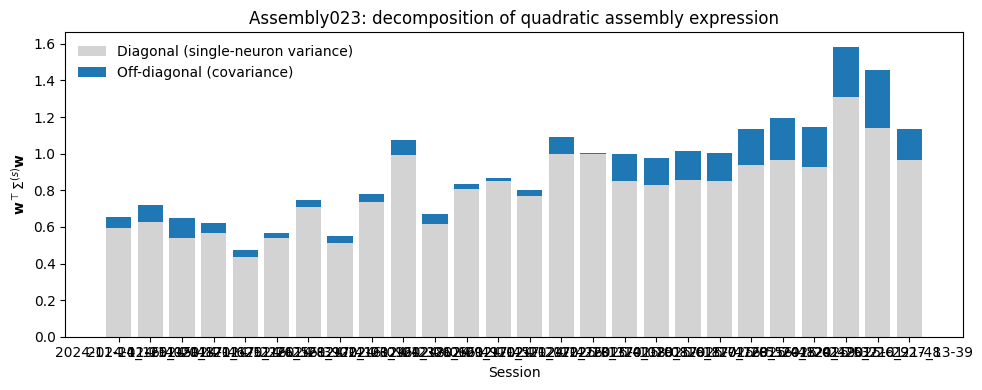

In [40]:
# plotting mean activity
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(metrics.index, metrics["diag_var"], label="Diagonal (single-neuron variance)", color="lightgray")
ax.bar(
    metrics.index,
    metrics["offdiag_var"],
    bottom=metrics["diag_var"],
    label="Off-diagonal (covariance)",
    color="tab:blue"
)

ax.set_ylabel(r"$\mathbf{w}^\top \Sigma^{(s)} \mathbf{w}$")
ax.set_xlabel("Session")
ax.set_title(f"{assembly_name}: decomposition of quadratic assembly expression")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

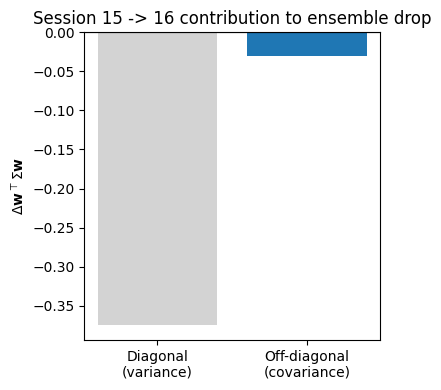

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))

vals = [dVar_diag, dVar_off]
labels = ["Diagonal\n(variance)", "Off-diagonal\n(covariance)"]
colors = ["lightgray", "tab:blue"]

ax.bar(labels, vals, color=colors)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel(r"$\Delta \mathbf{w}^\top \Sigma \mathbf{w}$")
ax.set_title("Session 15 -> 16 contribution to ensemble drop")

plt.tight_layout()
plt.show()


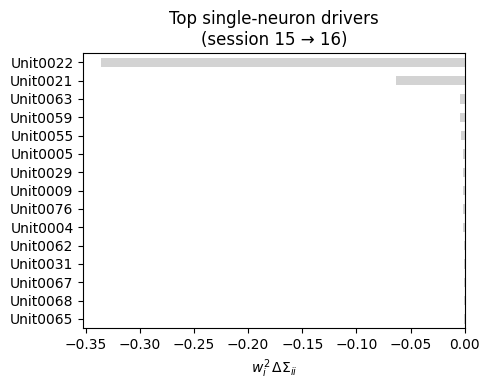

In [42]:
top_units = unit_driver.head(15)

fig, ax = plt.subplots(figsize=(5, 4))
top_units[::-1].plot(kind="barh", ax=ax, color="lightgray")

ax.set_xlabel(r"$w_i^2 \, \Delta \Sigma_{ii}$")
ax.set_title("Top single-neuron drivers\n(session 15 → 16)")

plt.tight_layout()
plt.show()


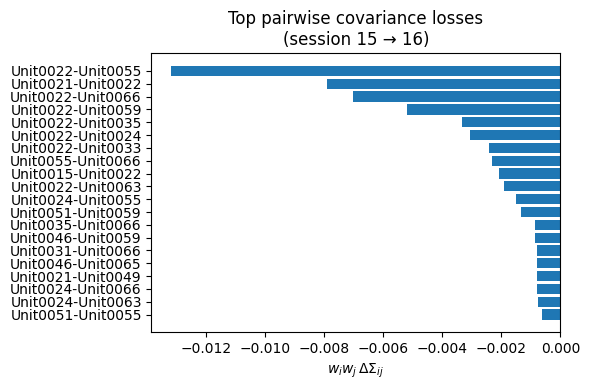

In [43]:
top_pairs = pair_driver.head(20)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(
    range(len(top_pairs)),
    top_pairs["pair_score"],
    color="tab:blue"
)
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(
    [f"{u}-{v}" for u, v in zip(top_pairs["unit_i"], top_pairs["unit_j"])]
)

ax.set_xlabel(r"$w_i w_j \, \Delta \Sigma_{ij}$")
ax.set_title("Top pairwise covariance losses\n(session 15 → 16)")

ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [44]:
fr.index.get_level_values("session_id").unique()

Index(['2024-11-14_16-40', '2024-11-15_15-48', '2024-11-20_17-46',
       '2024-11-21_17-22', '2024-11-25_16-25', '2024-11-26_16-39',
       '2024-11-28_17-41', '2024-12-02_16-09', '2024-12-03_16-23',
       '2024-12-04_18-06', '2024-12-06_16-49', '2024-12-09_17-45',
       '2024-12-10_17-20', '2024-12-11_17-42', '2024-12-12_16-13',
       '2024-12-13_17-10', '2025-01-14_18-08', '2025-01-15_17-18',
       '2025-01-16_17-47', '2025-01-17_16-55', '2025-01-23_16-48',
       '2025-01-24_12-24', '2025-01-24_19-37', '2025-01-25_21-29',
       '2025-01-26_21-48', '2025-01-27_13-39'],
      dtype='object', name='session_id')

In [45]:
# Decompose mean projection change for every consecutive session pair
valid_sessions = list(metrics[target].dropna().sort_index().index)

transition_unit_tables = []
transition_summary_rows = []
transition_pair_data = {}
transition_sep = "->"

for s_prev, s_next in zip(valid_sessions[:-1], valid_sessions[1:]):
    transition_label = f"{s_prev}{transition_sep}{s_next}"

    U_prev = units_by_session[s_prev]
    U_next = units_by_session[s_next]
    common_units = sorted(set(U_prev).intersection(U_next))

    X_prev = get_X_session_common(s_prev, common_units)
    X_next = get_X_session_common(s_next, common_units)

    w_common = w_raw.loc[common_units].astype(float).values
    if renorm_weights:
        nrm = np.linalg.norm(w_common)
        if nrm > 0:
            w_common = w_common / nrm

    w_series = pd.Series(w_common, index=common_units, name="w")
    mu_prev_units = pd.Series(X_prev.mean(axis=0), index=common_units, name="mu_prev")
    mu_next_units = pd.Series(X_next.mean(axis=0), index=common_units, name="mu_next")
    dmu_units = (mu_next_units - mu_prev_units).rename("dmu")
    contrib = (w_series * dmu_units).rename("w*dmu")

    y_prev = X_prev @ w_common
    y_next = X_next @ w_common
    dmu_y = float(y_next.mean() - y_prev.mean())
    sum_w_dmu = float(contrib.sum())

    transition_summary_rows.append(
        {
            "transition": transition_label,
            "session_prev": s_prev,
            "session_next": s_next,
            "n_common_units": len(common_units),
            "T_prev_common": int(X_prev.shape[0]),
            "T_next_common": int(X_next.shape[0]),
            "dmu_y": dmu_y,
            "sum_w_dmu": sum_w_dmu,
            "abs_err_check": abs(dmu_y - sum_w_dmu),
        }
    )

    unit_table = pd.concat([mu_prev_units, mu_next_units, dmu_units, w_series, contrib], axis=1).reset_index()
    unit_table = unit_table.rename(columns={"index": "unit"})
    unit_table["transition"] = transition_label
    unit_table["session_prev"] = s_prev
    unit_table["session_next"] = s_next
    transition_unit_tables.append(unit_table)

    transition_pair_data[transition_label] = {
        "session_prev": s_prev,
        "session_next": s_next,
        "y_prev": y_prev,
        "y_next": y_next,
    }
transition_unit_df = pd.concat(transition_unit_tables, ignore_index=True)
transition_summary_df = (
    pd.DataFrame(transition_summary_rows)
    .set_index("transition")
    .sort_values(["session_prev", "session_next"])
)

print("Per-transition projection-mean decomposition (all consecutive sessions):")
display(transition_summary_df)

# Each neuron's mean firing-rate change across consecutive transitions
dmu_by_unit_transition = transition_unit_df.pivot(index="unit", columns="transition", values="dmu")
display(dmu_by_unit_transition)

# Optional quick visualization: top units by average |\u0394mu| across transitions
top_n_units = min(30, dmu_by_unit_transition.shape[0])
units_rank = dmu_by_unit_transition.abs().mean(axis=1).sort_values(ascending=False)
top_units = units_rank.head(top_n_units).index
heatmap_data = dmu_by_unit_transition.loc[top_units].fillna(0.0)

vmax = np.nanmax(np.abs(heatmap_data.to_numpy()))
if vmax == 0:
    vmax = 1.0

x_transition_labels = [
    f"{str(c).split(transition_sep)[0].split('_')[0]}{transition_sep}{str(c).split(transition_sep)[1].split('_')[0]}"
    for c in heatmap_data.columns
]

fig = px.imshow(
    heatmap_data.to_numpy(),
    x=x_transition_labels,
    y=heatmap_data.index,
    color_continuous_scale="RdBu_r",
    zmin=-vmax,
    zmax=vmax,
    aspect="auto",
    labels={"x": "Session transition", "y": "Neuron", "color": "∆µ"},
)

fig.update_layout(
    title="Per-neuron mean firing-rate change ∆µ across consecutive sessions",
    # width=max(800, int(120 * heatmap_data.shape[1])),
    height=max(600, int(25 * heatmap_data.shape[0])),
)
fig.update_xaxes(tickangle=-45, side="bottom")
fig.show()

Per-transition projection-mean decomposition (all consecutive sessions):


,session_prev,session_next,n_common_units,T_prev_common,T_next_common,dmu_y,sum_w_dmu,abs_err_check
transition,,,,,,,,
2024-11-14_16-40->2024-11-15_15-48,2024-11-14_16-40,2024-11-15_15-48,77,32200,53592,-0.364623,-0.364623,2.681189e-14
2024-11-15_15-48->2024-11-20_17-46,2024-11-15_15-48,2024-11-20_17-46,77,53592,33834,-0.169537,-0.169537,1.015854e-14
2024-11-20_17-46->2024-11-21_17-22,2024-11-20_17-46,2024-11-21_17-22,77,33834,38805,0.005732,0.005732,1.697123e-13
2024-11-21_17-22->2024-11-25_16-25,2024-11-21_17-22,2024-11-25_16-25,77,38805,27459,0.092079,0.092079,2.666062e-13
2024-11-25_16-25->2024-11-26_16-39,2024-11-25_16-25,2024-11-26_16-39,77,27459,38213,0.111323,0.111323,1.460776e-13
2024-11-26_16-39->2024-11-28_17-41,2024-11-26_16-39,2024-11-28_17-41,77,38213,46119,-0.308443,-0.308443,4.540812e-14
2024-11-28_17-41->2024-12-02_16-09,2024-11-28_17-41,2024-12-02_16-09,77,46119,42833,0.394656,0.394656,5.162537e-15
2024-12-02_16-09->2024-12-03_16-23,2024-12-02_16-09,2024-12-03_16-23,77,42833,45100,-0.309030,-0.309030,6.467049e-14
2024-12-03_16-23->2024-12-04_18-06,2024-12-03_16-23,2024-12-04_18-06,77,45100,45795,-0.138987,-0.138987,2.090550e-13


transition,2024-11-14_16-40->2024-11-15_15-48,2024-11-15_15-48->2024-11-20_17-46,2024-11-20_17-46->2024-11-21_17-22,2024-11-21_17-22->2024-11-25_16-25,2024-11-25_16-25->2024-11-26_16-39,2024-11-26_16-39->2024-11-28_17-41,2024-11-28_17-41->2024-12-02_16-09,2024-12-02_16-09->2024-12-03_16-23,2024-12-03_16-23->2024-12-04_18-06,2024-12-04_18-06->2024-12-06_16-49,...,2024-12-13_17-10->2025-01-14_18-08,2025-01-14_18-08->2025-01-15_17-18,2025-01-15_17-18->2025-01-16_17-47,2025-01-16_17-47->2025-01-17_16-55,2025-01-17_16-55->2025-01-23_16-48,2025-01-23_16-48->2025-01-24_12-24,2025-01-24_12-24->2025-01-24_19-37,2025-01-24_19-37->2025-01-25_21-29,2025-01-25_21-29->2025-01-26_21-48,2025-01-26_21-48->2025-01-27_13-39
unit,,,,,,,,,,,,,,,,,,,,,
Unit0001,-0.234736,-0.032636,0.002200,-0.063521,0.000611,0.000271,0.051049,-0.053513,0.021190,-0.013929,...,0.290321,-0.216696,-0.003023,-0.009900,0.351551,-0.005646,-0.066477,0.391785,-0.658792,-2.132251e-02
Unit0002,0.061252,0.509100,-0.174414,-0.077196,0.063669,0.021087,-0.189303,0.141566,-0.061337,0.064880,...,0.067577,0.000137,-0.018644,0.010242,0.000608,-0.066882,0.036959,0.230532,-0.221407,9.017103e-02
Unit0003,-0.016835,-0.052730,-0.020438,0.010519,0.009696,0.082195,0.186371,-0.006465,-0.115222,-0.092950,...,0.349182,-0.440536,-0.004951,0.000386,0.010326,0.021486,-0.041436,-0.014592,-0.001180,1.207368e-14
Unit0004,0.003211,0.002845,-0.005699,-0.002827,0.005760,-0.004233,0.002186,-0.001320,0.007331,-0.005542,...,0.119064,0.016055,-0.027033,-0.005073,0.068928,0.087311,-0.109208,0.341850,-0.270314,-3.855969e-02
Unit0005,0.026810,-0.022223,-0.064636,-0.045935,0.030640,-0.006976,0.140819,-0.139016,0.027815,-0.027452,...,-0.030242,-0.004786,0.001609,-0.003529,0.014958,-0.037359,0.007616,0.281711,-0.216656,-6.400145e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unit0073,0.343150,-0.447755,-0.008695,0.021134,-0.022649,0.006462,0.016667,-0.006018,-0.006860,0.013697,...,-0.071166,-0.000371,0.005760,-0.012066,0.043923,0.189612,-0.100230,0.241059,-0.118864,-2.100804e-01
Unit0074,0.054564,0.000576,-0.135642,-0.093650,0.129412,-0.122857,0.018353,-0.039146,-0.000062,0.023065,...,0.110135,0.221638,-0.007204,-0.058137,0.783597,-0.248481,0.543901,-0.044512,0.446772,-5.592613e-01
Unit0075,0.003839,0.131916,-0.066750,0.000764,0.025436,-0.064591,0.035323,0.028710,0.019322,0.021940,...,-0.150189,0.220976,0.138215,0.038111,-0.352226,-0.181625,0.127366,0.209773,-0.320809,-3.224432e-01


In [46]:
# Weighted version: per-neuron weighted change w_i * Δmu_i across consecutive sessions
weighted_by_unit_transition = transition_unit_df.pivot(index="unit", columns="transition", values="w*dmu")

top_n_units_w = min(30, weighted_by_unit_transition.shape[0])
units_rank_w = weighted_by_unit_transition.abs().mean(axis=1).sort_values(ascending=False)
top_units_w = units_rank_w.head(top_n_units_w).index
weighted_heatmap_data = weighted_by_unit_transition.loc[top_units_w].fillna(0.0)

vmax_w = np.nanmax(np.abs(weighted_heatmap_data.to_numpy()))
if vmax_w == 0:
    vmax_w = 1.0

transition_sep = "->"

x_transition_labels_w = [
    f"{str(c).split(transition_sep)[0].split('_')[0]}{transition_sep}{str(c).split(transition_sep)[1].split('_')[0]}"
    for c in weighted_heatmap_data.columns
]

fig_w = px.imshow(
    weighted_heatmap_data.to_numpy(),
    x=x_transition_labels_w,
    y=weighted_heatmap_data.index,
    color_continuous_scale="RdBu_r",
    zmin=-vmax_w,
    zmax=vmax_w,
    aspect="auto",
    labels={"x": "Session transition", "y": "Neuron", "color": "∆µ "},
)

fig_w.update_layout(
    title="Per-neuron (weighted) mean firing-rate change ∆µ across consecutive sessions",
    #width=max(800, int(120 * weighted_heatmap_data.shape[1])),
    height=max(600, int(15 * weighted_heatmap_data.shape[0])),
)
fig_w.update_xaxes(tickangle=-45, side="bottom")
fig_w.show()


In [47]:
# Same weighted heatmap, but neurons ordered by |Assembly023| weight in `ensambles`
assembly_col = "Assembly023"
top_k = 20

if "weighted_by_unit_transition" not in globals():
    weighted_by_unit_transition = transition_unit_df.pivot(index="unit", columns="transition", values="w*dmu")

if "ensambles" not in globals():
    raise RuntimeError("`ensambles` is not defined. Run the ensemble-loading cell first.")
if assembly_col not in ensambles.columns:
    raise KeyError(f"{assembly_col} not found in ensambles.")

w_assembly = ensambles[assembly_col].dropna().astype(float).copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_assembly.index):
    try:
        w_assembly.index = [f"Unit{int(i)+1:04d}" for i in w_assembly.index]
    except Exception:
        w_assembly.index = w_assembly.index.astype(str)

neurons_by_abs_weight = w_assembly.abs().sort_values(ascending=False).index
neurons_present = [u for u in neurons_by_abs_weight if u in weighted_by_unit_transition.index][:top_k]

if len(neurons_present) == 0:
    raise RuntimeError("No overlap between Assembly023 units and weighted transition units.")

weighted_heatmap_absw_order = weighted_by_unit_transition.loc[neurons_present].fillna(0.0)

vmax_absw = np.nanmax(np.abs(weighted_heatmap_absw_order.to_numpy()))
if vmax_absw == 0:
    vmax_absw = 1.0

transition_sep = "->"
x_transition_labels_absw = [
    f"{str(c).split(transition_sep)[0].split('_')[0]}{transition_sep}{str(c).split(transition_sep)[1].split('_')[0]}"
    for c in weighted_heatmap_absw_order.columns
]

fig_w_absorder = px.imshow(
    weighted_heatmap_absw_order.to_numpy(),
    x=x_transition_labels_absw,
    y=weighted_heatmap_absw_order.index,
    color_continuous_scale="RdBu_r",
    zmin=-vmax_absw,
    zmax=vmax_absw,
    aspect="auto",
    labels={"x": "Session transition", "y": "Neuron (top 20 by |Assembly023 weight|)", "color": "w*∆µ"},
)

fig_w_absorder.update_layout(
    title="Per-neuron weighted change (w*∆µ), top 20 neurons by |Assembly023 weight|",
    height=max(550, int(14 * weighted_heatmap_absw_order.shape[0])),
)
fig_w_absorder.update_xaxes(tickangle=-45, side="bottom")
fig_w_absorder.show()


In [48]:
# Same neuron ordering, but show session-wise mean firing rates instead of transition deltas
assembly_col = "Assembly023"
top_k = 20

if "ensambles" not in globals():
    raise RuntimeError("`ensambles` is not defined. Run the ensemble-loading cell first.")
if assembly_col not in ensambles.columns:
    raise KeyError(f"{assembly_col} not found in ensambles.")

if "fr" in globals():
    fr_source = fr
    fr_label = "Mean FR (Hz)"
    title_suffix = "mean firing rate"
elif "fr_z_all_sess" in globals():
    fr_source = fr_z_all_sess
    fr_label = "Mean FR (z-score)"
    title_suffix = "mean z-scored firing rate"
else:
    raise RuntimeError("Neither `fr` nor `fr_z_all_sess` is defined. Run the firing-rate loading cell first.")

w_assembly = ensambles[assembly_col].dropna().astype(float).copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_assembly.index):
    try:
        w_assembly.index = [f"Unit{int(i)+1:04d}" for i in w_assembly.index]
    except Exception:
        w_assembly.index = w_assembly.index.astype(str)

fr_unit_cols = [c for c in fr_source.columns if isinstance(c, str) and c.startswith("Unit")]
if len(fr_unit_cols) == 0:
    raise RuntimeError("No Unit#### columns found in the firing-rate table.")

fr_units = fr_source.loc[:, fr_unit_cols].apply(pd.to_numeric, errors="coerce")
if isinstance(fr_units.index, pd.MultiIndex):
    if "session_id" not in fr_units.index.names:
        raise RuntimeError("Could not find `session_id` in the firing-rate table index.")
    session_mean_fr = fr_units.groupby(level="session_id").mean()
elif fr_units.index.name == "session_id":
    session_mean_fr = fr_units.groupby(level=0).mean()
else:
    raise RuntimeError("Could not find `session_id` in the firing-rate table index.")

neurons_by_abs_weight = w_assembly.abs().sort_values(ascending=False).index
neurons_present = [u for u in neurons_by_abs_weight if u in session_mean_fr.columns][:top_k]

if len(neurons_present) == 0:
    raise RuntimeError("No overlap between Assembly023 units and per-session firing-rate units.")

if "transition_summary_df" in globals() and not transition_summary_df.empty:
    session_order = [transition_summary_df.iloc[0]["session_prev"], *transition_summary_df["session_next"].tolist()]
    session_order = [s for s in session_order if s in session_mean_fr.index]
else:
    session_order = session_mean_fr.index.tolist()

if len(session_order) == 0:
    raise RuntimeError("No sessions available for the firing-rate heatmap.")

session_fr_heatmap = session_mean_fr.loc[session_order, neurons_present].T
heatmap_values = session_fr_heatmap.to_numpy(dtype=float)

if not np.isfinite(heatmap_values).any():
    raise RuntimeError("Firing-rate heatmap contains only non-finite values.")

imshow_kwargs = dict(
    x=[str(s).replace("_", "<br>") for s in session_fr_heatmap.columns],
    y=session_fr_heatmap.index,
    aspect="auto",
    labels={"x": "Session", "y": "Neuron (top 20 by |Assembly023 weight|)", "color": fr_label},
)

if np.nanmin(heatmap_values) < 0:
    vmax = np.nanmax(np.abs(heatmap_values))
    if vmax == 0:
        vmax = 1.0
    fig_fr_absorder = px.imshow(
        heatmap_values,
        color_continuous_scale="RdBu_r",
        zmin=-vmax,
        zmax=vmax,
        **imshow_kwargs,
    )
else:
    fig_fr_absorder = px.imshow(
        heatmap_values,
        color_continuous_scale="Viridis",
        **imshow_kwargs,
    )

fig_fr_absorder.update_layout(
    title=f"Per-neuron {title_suffix}, top 20 neurons by |Assembly023 weight|",
    height=max(550, int(14 * session_fr_heatmap.shape[0])),
)
fig_fr_absorder.update_xaxes(tickangle=-45, side="bottom")
fig_fr_absorder.show()


In [49]:
quad_rows = []
for transition_label, pair in transition_pair_data.items():
    y_prev = pair["y_prev"]
    y_next = pair["y_next"]

    mu_prev = float(y_prev.mean())
    mu_next = float(y_next.mean())
    var_prev = float(y_prev.var(ddof=1))
    var_next = float(y_next.var(ddof=1))

    Ey2_prev = float((y_prev**2).mean())
    Ey2_next = float((y_next**2).mean())

    dEy2 = Ey2_next - Ey2_prev
    dVar = var_next - var_prev
    dMu2 = mu_next**2 - mu_prev**2

    quad_rows.append(
        {
            "transition": transition_label,
            "session_prev": pair["session_prev"],
            "session_next": pair["session_next"],
            "dE_y2": dEy2,
            "dVar_y": dVar,
            "dmu_y2": dMu2,
            "sum_check": dVar + dMu2,
            "abs_err_check": abs(dEy2 - (dVar + dMu2)),
        }
    )

quad_decomp_df = (
    pd.DataFrame(quad_rows)
    .set_index("transition")
    .loc[transition_summary_df.index]
)

print("Mean quadratic activity decomposition (all consecutive transitions):")
display(quad_decomp_df)


Mean quadratic activity decomposition (all consecutive transitions):


,session_prev,session_next,dE_y2,dVar_y,dmu_y2,sum_check,abs_err_check
transition,,,,,,,
2024-11-14_16-40->2024-11-15_15-48,2024-11-14_16-40,2024-11-15_15-48,-0.245401,0.065635,-0.311043,-0.245408,6.856266e-06
2024-11-15_15-48->2024-11-20_17-46,2024-11-15_15-48,2024-11-20_17-46,-0.120664,-0.066594,-0.054064,-0.120658,5.850190e-06
2024-11-20_17-46->2024-11-21_17-22,2024-11-20_17-46,2024-11-21_17-22,-0.026258,-0.027150,0.000889,-0.026261,3.164165e-06
2024-11-21_17-22->2024-11-25_16-25,2024-11-21_17-22,2024-11-25_16-25,-0.124866,-0.148152,0.023287,-0.124865,1.246581e-06
2024-11-25_16-25->2024-11-26_16-39,2024-11-25_16-25,2024-11-26_16-39,0.143720,0.092921,0.050796,0.143718,2.442882e-06
2024-11-26_16-39->2024-11-28_17-41,2024-11-26_16-39,2024-11-28_17-41,0.096278,0.176222,-0.079942,0.096280,1.270505e-06
2024-11-28_17-41->2024-12-02_16-09,2024-11-28_17-41,2024-12-02_16-09,-0.058435,-0.194749,0.136311,-0.058438,3.307827e-06
2024-12-02_16-09->2024-12-03_16-23,2024-12-02_16-09,2024-12-03_16-23,0.098917,0.232119,-0.133197,0.098921,4.501293e-06
2024-12-03_16-23->2024-12-04_18-06,2024-12-03_16-23,2024-12-04_18-06,0.294217,0.291861,0.002363,0.294223,6.110010e-06


In [50]:
# calculate std for all UNIt columns in fr and calculate average
avg_std = []
for col in fr.columns:
    if isinstance(col, str) and col.startswith('Unit'):
        # print(f"{col}: {fr[col].std()}")
        avg_std.append(fr[col].std())
average_std = np.mean(avg_std)

# means of neuron frs
means = []
for col in fr.columns: 
    if isinstance(col, str) and col.startswith('Unit'):
        print(f"{col}: {fr[col].mean()}")
        means.append(fr[col].mean())

print(min(means))
print(f'average std {avg_std}')

Unit0001: 0.832321939689819
Unit0002: 3.3249423714353594
Unit0003: 0.20474554246752724
Unit0004: 0.34419642213331575
Unit0005: 0.4295671538813607
Unit0006: 0.5751471169778267
Unit0007: 5.603386441936138
Unit0008: 2.597061531443526
Unit0009: 0.137382551201566
Unit0010: 0.3682193931030923
Unit0011: 0.0529795694688912
Unit0012: 3.0899878480958853
Unit0013: 0.06387150101442972
Unit0014: 0.03149931422577342
Unit0015: 28.297921272966985
Unit0016: 5.377672982468924
Unit0017: 2.913117301169118
Unit0018: 0.03001922596697202
Unit0019: 1.9311546434163778
Unit0020: 2.7838183089194675
Unit0021: 3.5133500165845786
Unit0022: 8.1316048938549
Unit0023: 4.52497136598484
Unit0024: 22.94842689388678
Unit0025: 9.285352667081092
Unit0026: 2.3512530275395087
Unit0027: 5.511791749304928
Unit0028: 1.0240502956760928
Unit0029: 13.687400805623424
Unit0030: 0.8938404798825644
Unit0031: 2.889359987066306
Unit0032: 2.5610270749888615
Unit0033: 9.41525887502666
Unit0034: 5.411696036930858
Unit0035: 5.911396603690809

In [51]:
sessions = [16, ]
assembly_name = "Assembly023"
target = "rms_a"                 # "var_a" 
min_T = 200
min_finite_frac_per_unit = 0.99  # keep units that are finite in >=99% of rows for that session
min_units = 10
renorm_weights = True


Z_df = fr_z_all_sess.copy()#.loc[fr.index.get_level_values("session_id").isin(sessions)]
unit_cols = [c for c in Z_df.columns if isinstance(c, str) and c.startswith("Unit")]

w_raw = ensambles[assembly_name].copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_raw.index):
    try:
        w_raw.index = [f"Unit{int(i)+1:04d}" for i in w_raw.index]
    except Exception as e:
        raise ValueError("Could not map weight index to UnitXXXX.") from e

# Use only units present in data
units_all = [u for u in w_raw.index if u in unit_cols]
if len(units_all) < 2:
    raise ValueError("Too few overlapping units between weights and fr_z_scored.")

Z_units = Z_df[units_all]

def iter_sessions(Z: pd.DataFrame):
    if isinstance(Z.index, pd.MultiIndex) and "session_id" in Z.index.names:
        for s in sorted(Z.index.get_level_values("session_id").unique()):
            yield s, Z.xs(s, level="session_id")
        return
    if Z.index.name == "session_id":
        for s in sorted(Z.index.unique()):
            yield s, Z.loc[s]
        return
    if "session_id" in Z.columns:
        for s, g in Z.groupby("session_id", sort=True):
            yield s, g.drop(columns=["session_id"])
        return
    raise ValueError("Cannot find session_id in fr_z_scored (neither index level nor column).")


# Per-session computation with column-wise filtering

rows = []
Sigma_by_session = {}
units_by_session = {}
w_by_session = {}

for s, Z_s in iter_sessions(Z_units):
    X = np.asarray(Z_s.values, dtype=float)  # shape (T, N_all)
    T_raw, N_all = X.shape

    if T_raw == 0:
        rows.append({"session_id": s, "T_raw": 0, "T_used": 0, "N_used": 0,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # keep units that are finite in most rows (per-session)
    finite_mask = np.isfinite(X)  # (T, N_all)
    finite_frac = finite_mask.mean(axis=0)  # (N_all,)
    keep_cols = finite_frac >= min_finite_frac_per_unit

    if keep_cols.sum() < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": 0, "N_used": int(keep_cols.sum()),
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    kept_units = list(np.array(units_all)[keep_cols])

    # subset X and drop rows that still have any NaN/inf (rare after column filter)
    Xk = X[:, keep_cols]
    ok_rows = np.isfinite(Xk).all(axis=1)
    Xk = Xk[ok_rows, :]
    T_used, N_used = Xk.shape

    if T_used < min_T or N_used < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # align weights to kept units
    w_s = w_raw.loc[kept_units].astype(float).values

    # Optional: renormalize weights so that comparisons across sessions are not dominated by changing N_used
    if renorm_weights:
        norm = np.linalg.norm(w_s)
        if norm > 0:
            w_s = w_s / norm

    # assembly activation and covariance decomposition
    a = Xk @ w_s
    mean_a = float(np.mean(a))

    Sigma = np.cov(Xk, rowvar=False, bias=False)
    var_a = float(w_s.T @ Sigma @ w_s)
    diag_var = float(np.sum((w_s ** 2) * np.diag(Sigma)))
    offdiag_var = float(var_a - diag_var)

    rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                 "mean_a": mean_a, "var_a": var_a, "diag_var": diag_var, "offdiag_var": offdiag_var})

    Sigma_by_session[s] = Sigma
    units_by_session[s] = kept_units
    w_by_session[s] = w_s

metrics = pd.DataFrame(rows).set_index("session_id").sort_index()
metrics["rms_a"] = np.sqrt(metrics["var_a"])
metrics["diag_frac"] = metrics["diag_var"] / metrics["var_a"]
metrics["offdiag_frac"] = metrics["offdiag_var"] / metrics["var_a"]

display(metrics)

# Find largest drop safely
valid = metrics[target].dropna()
if valid.shape[0] < 2:
    raise ValueError(
        f"Not enough valid sessions for target={target}. "
        f"Valid sessions={valid.shape[0]}. "
        f"Try lowering min_T, lowering min_finite_frac_per_unit, or check why many units are NaN."
    )

delta = valid.diff().dropna()
drop_session = delta.idxmin()
prev_session = valid.index[valid.index.get_loc(drop_session) - 1]

print(f"\nLargest drop in {target}: session {prev_session} -> {drop_session} (Δ={delta.loc[drop_session]:.6g})")
print(f"Session sizes: prev(T={metrics.loc[prev_session,'T_used']}, N={metrics.loc[prev_session,'N_used']}), "
      f"drop(T={metrics.loc[drop_session,'T_used']}, N={metrics.loc[drop_session,'N_used']})")


# Attribution for that drop (only on common kept units)
U_prev = units_by_session[prev_session]
U_drop = units_by_session[drop_session]
common_units = sorted(set(U_prev).intersection(U_drop))

if len(common_units) < min_units:
    raise ValueError(
        f"Too few common units between prev and drop sessions for attribution: {len(common_units)}. "
        f"This indicates strong session-to-session changes in which units are finite."
    )

# Recompute Sigma on common units only (consistent dimensionality)
def get_X_session_common(s, common_units):
    Z_s = next(g for sid, g in iter_sessions(Z_units) if sid == s)  # session df with all units_all
    X = Z_s[common_units].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1)
    return X[ok, :]

X_prev = get_X_session_common(prev_session, common_units)
X_drop = get_X_session_common(drop_session, common_units)

if X_prev.shape[0] < min_T or X_drop.shape[0] < min_T:
    raise ValueError("After restricting to common units, not enough finite rows remain for covariance.")

Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
Sigma_drop = np.cov(X_drop, rowvar=False, bias=False)
dSigma = Sigma_drop - Sigma_prev

# weights restricted to common units (and optionally renormalized)
w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    norm = np.linalg.norm(w_common)
    if norm > 0:
        w_common = w_common / norm

dVar_total = float(w_common.T @ dSigma @ w_common)
dVar_diag  = float(np.sum((w_common ** 2) * np.diag(dSigma)))
dVar_off   = float(dVar_total - dVar_diag)

print(f"\nAttribution on common units (N={len(common_units)}):")
print(f" delta Var(a) total:   {dVar_total:.6g}")
print(f"  diagonal part: {dVar_diag:.6g}")
print(f"  offdiag part:  {dVar_off:.6g}")

# unit and pair driver scores
unit_driver = pd.Series((w_common ** 2) * np.diag(dSigma), index=common_units).sort_values()

C = np.outer(w_common, w_common) * dSigma
np.fill_diagonal(C, 0.0)

pair_rows = []
N = len(common_units)
for i in range(N):
    for j in range(i + 1, N):
        pair_rows.append((common_units[i], common_units[j], C[i, j]))

pair_driver = pd.DataFrame(pair_rows, columns=["unit_i", "unit_j", "pair_score"]).sort_values("pair_score")

print("\nTop unit-level diagonal drivers (most negative):")
display(unit_driver.head(15).to_frame("d_i = w_i^2 * Sigma_ii"))

print("\nTop pair-level off diagonal drivers (most negative):")
display(pair_driver.head(20))


,T_raw,T_used,N_used,mean_a,var_a,diag_var,offdiag_var,rms_a,diag_frac,offdiag_frac
session_id,,,,,,,,,,
2024-11-14_16-40,32200,32200,77,0.608838,0.651881,0.594716,0.057165,0.807392,0.912308,0.087692
2024-11-15_15-48,53592,53592,77,0.244214,0.717516,0.628667,0.088849,0.847063,0.876172,0.123828
2024-11-20_17-46,33834,33834,77,0.074677,0.650922,0.537797,0.113125,0.806797,0.826208,0.173792
2024-11-21_17-22,38805,38805,77,0.080409,0.623772,0.568115,0.055656,0.789792,0.910774,0.089226
2024-11-25_16-25,27459,27459,77,0.172488,0.475620,0.434427,0.041193,0.689652,0.913390,0.086610
2024-11-26_16-39,38213,38213,77,0.283811,0.568541,0.540365,0.028176,0.754017,0.950442,0.049558
2024-11-28_17-41,46119,46119,77,-0.024632,0.744763,0.707378,0.037385,0.862996,0.949803,0.050197
2024-12-02_16-09,42833,42833,77,0.370024,0.550014,0.510590,0.039424,0.741629,0.928321,0.071679
2024-12-03_16-23,45100,45100,77,0.060994,0.782133,0.733512,0.048620,0.884383,0.937836,0.062164



Largest drop in rms_a: session 2024-12-04_18-06 -> 2024-12-06_16-49 (Δ=-0.219018)
Session sizes: prev(T=45795, N=77), drop(T=38471, N=77)

Attribution on common units (N=77):
 delta Var(a) total:   -0.405983
  diagonal part: -0.375244
  offdiag part:  -0.0307391

Top unit-level diagonal drivers (most negative):


,d_i = w_i^2 * Sigma_ii
Unit0022,-0.335471
Unit0021,-0.063547
Unit0063,-0.004677
Unit0059,-0.004328
Unit0055,-0.003730
Unit0005,-0.001852
Unit0029,-0.001618
Unit0009,-0.001577
Unit0076,-0.001570
Unit0004,-0.001183



Top pair-level off diagonal drivers (most negative):


,unit_i,unit_j,pair_score
1418,Unit0022,Unit0055,-0.013195
1330,Unit0021,Unit0022,-0.007915
1429,Unit0022,Unit0066,-0.007029
1422,Unit0022,Unit0059,-0.005194
1398,Unit0022,Unit0035,-0.003347
1387,Unit0022,Unit0024,-0.003066
1396,Unit0022,Unit0033,-0.002407
2683,Unit0055,Unit0066,-0.002300
979,Unit0015,Unit0022,-0.002093
1426,Unit0022,Unit0063,-0.001912


In [52]:
# Session-to-session decomposition of ensemble differences:
# covariance structure (diag/off-diag of Sigma) vs firing-rate shift term.
required = ["transition_summary_df", "units_by_session", "w_raw"]
missing = [name for name in required if name not in globals()]
if "get_X_session_common" not in globals():
    missing.append("get_X_session_common")
if missing:
    raise RuntimeError(
        f"Missing required objects: {missing}. Run the decomposition cells above first."
    )

rows = []
for transition_label, r in transition_summary_df.iterrows():
    s_prev = r["session_prev"]
    s_next = r["session_next"]

    common_units = sorted(set(units_by_session[s_prev]).intersection(units_by_session[s_next]))
    if len(common_units) < 2:
        continue

    X_prev = get_X_session_common(s_prev, common_units)
    X_next = get_X_session_common(s_next, common_units)
    if X_prev.shape[0] < 2 or X_next.shape[0] < 2:
        continue

    w_common = w_raw.loc[common_units].astype(float).values
    if "renorm_weights" in globals() and renorm_weights:
        nrm = np.linalg.norm(w_common)
        if nrm > 0:
            w_common = w_common / nrm

    Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
    Sigma_next = np.cov(X_next, rowvar=False, bias=False)
    dSigma = Sigma_next - Sigma_prev

    dVar_total = float(w_common.T @ dSigma @ w_common)
    dVar_diag = float(np.sum((w_common ** 2) * np.diag(dSigma)))
    dVar_off = float(dVar_total - dVar_diag)

    y_prev = X_prev @ w_common
    y_next = X_next @ w_common
    dmu_y2 = float(y_next.mean() ** 2 - y_prev.mean() ** 2)
    dE_y2 = float((y_next ** 2).mean() - (y_prev ** 2).mean())

    rows.append(
        {
            "transition": transition_label,
            "dVar_diag": dVar_diag,
            "dVar_off": dVar_off,
            "dVar_total": dVar_total,
            "dmu_y2": dmu_y2,
            "dE_y2": dE_y2,
            "abs_check": abs(dE_y2 - (dVar_total + dmu_y2)),
        }
    )

plot_df = pd.DataFrame(rows).set_index("transition")
if plot_df.empty:
    raise RuntimeError("No valid transitions found for decomposition plot.")

display(plot_df[["dVar_diag", "dVar_off", "dVar_total", "dmu_y2", "dE_y2", "abs_check"]])

x_labels = [
    f"{t.split('->')[0].split('_')[0]}->{t.split('->')[1].split('_')[0]}"
    for t in plot_df.index
]

abs_parts = plot_df[["dVar_diag", "dVar_off", "dmu_y2"]].abs()
abs_total = abs_parts.sum(axis=1).replace(0, np.nan)
abs_share = abs_parts.div(abs_total, axis=0) * 100.0

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.78, 0.22],
    vertical_spacing=0.08,
    subplot_titles=(
        "Decomposition of Delta E[y^2] across session transitions",
        "Absolute contribution shares (percent of |diag|+|offdiag|+|rate|)",
    ),
)

fig.add_trace(
    go.Bar(x=x_labels, y=plot_df["dVar_diag"], name="Variance (diag variance)", marker_color="#1f77b4"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=plot_df["dVar_off"], name="Covariance (offdiag variance)", marker_color="#17becf"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=plot_df["dmu_y2"], name="Firing-rate shift (Delta mu_y^2)", marker_color="#ff7f0e"),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=x_labels,
        y=plot_df["dE_y2"],
        mode="lines+markers",
        name="Total Delta E[y^2]",
        line=dict(color="black", width=2),
        marker=dict(size=6),
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=x_labels, y=abs_share["dVar_diag"], name="|diag variance| share", marker_color="#4c78a8", showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=abs_share["dVar_off"], name="|offdiag variance| share", marker_color="#72b7b2", showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=abs_share["dmu_y2"], name="|∆ mu_y^2| share", marker_color="#f58518", showlegend=False),
    row=2, col=1
)

fig.update_layout(
    title="Variance/covariance-driven vs firing-rate-driven ensemble differences",
    barmode="relative",
    width=1400,
    height=700,
    plot_bgcolor="white",
    legend=dict(
        orientation="v",
        x=0.99,
        y=0.30,
        xanchor="right",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
    ),
)
fig.update_yaxes(title_text="Contribution to ∆ E[y^2]", row=1, col=1, zeroline=True, zerolinewidth=1)
fig.update_yaxes(title_text="Absolute share (%)", row=2, col=1, range=[0, 100])
fig.update_xaxes(tickangle=-45, row=2, col=1)

fig.show()


,dVar_diag,dVar_off,dVar_total,dmu_y2,dE_y2,abs_check
transition,,,,,,
2024-11-14_16-40->2024-11-15_15-48,0.033951,0.031684,0.065635,-0.311043,-0.245401,6.856266e-06
2024-11-15_15-48->2024-11-20_17-46,-0.090870,0.024276,-0.066594,-0.054064,-0.120664,5.850190e-06
2024-11-20_17-46->2024-11-21_17-22,0.030318,-0.057468,-0.027150,0.000889,-0.026258,3.164165e-06
2024-11-21_17-22->2024-11-25_16-25,-0.133689,-0.014463,-0.148152,0.023287,-0.124866,1.246581e-06
2024-11-25_16-25->2024-11-26_16-39,0.105939,-0.013018,0.092921,0.050796,0.143720,2.442882e-06
2024-11-26_16-39->2024-11-28_17-41,0.167013,0.009209,0.176222,-0.079942,0.096278,1.270505e-06
2024-11-28_17-41->2024-12-02_16-09,-0.196788,0.002040,-0.194749,0.136311,-0.058435,3.307827e-06
2024-12-02_16-09->2024-12-03_16-23,0.222922,0.009196,0.232119,-0.133197,0.098917,4.501293e-06
2024-12-03_16-23->2024-12-04_18-06,0.259023,0.032838,0.291861,0.002363,0.294217,6.110010e-06


In [53]:
ensambles

,Assembly001,Assembly002,Assembly003,Assembly004,Assembly005,Assembly006,Assembly007,Assembly008,Assembly009,Assembly010,...,Assembly014,Assembly015,Assembly016,Assembly017,Assembly018,Assembly019,Assembly020,Assembly021,Assembly022,Assembly023
0,-0.007620,-0.026573,-0.010349,0.013573,-0.598716,-0.011359,0.006246,0.003455,-0.012089,0.001278,...,0.002649,0.008498,-0.012974,0.002732,0.013380,0.030109,-0.004973,0.027152,-0.001781,0.017863
1,0.045658,0.175509,0.077437,-0.004664,-0.026553,-0.003270,-0.007405,-0.052149,0.180782,0.020086,...,-0.008011,-0.010138,-0.012111,0.001653,-0.516077,0.035318,-0.048191,-0.020027,0.048238,-0.087214
2,0.010040,-0.012086,-0.005691,-0.002109,0.032244,0.006258,0.017659,0.038180,-0.028504,-0.021451,...,0.000443,0.001398,-0.007994,0.010366,-0.699748,0.001800,0.055084,-0.022802,-0.037287,-0.007965
3,0.004320,-0.000709,0.020682,0.030223,-0.173876,-0.019167,0.025496,-0.022999,0.002305,0.017461,...,-0.013267,-0.003933,-0.022325,-0.007743,-0.078004,0.005915,-0.058495,-0.009877,-0.005245,-0.135142
4,0.012085,0.011409,-0.031820,0.023285,-0.634643,0.014083,-0.026461,0.028788,0.024019,0.012473,...,-0.001875,-0.001851,-0.000643,0.006167,0.037504,-0.049953,-0.023400,-0.002684,0.020493,0.078588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,-0.008495,0.008644,-0.003513,0.004848,-0.016281,0.635420,-0.008987,-0.019280,-0.000862,0.030654,...,0.016379,0.013851,0.009954,0.000234,-0.003852,-0.010269,0.027721,0.053196,-0.013451,0.035508
73,-0.060573,0.015221,0.052229,-0.048880,0.002319,0.004589,-0.004035,-0.223293,0.004947,-0.027151,...,-0.015887,-0.014372,0.000399,-0.014106,0.005821,-0.124696,0.053304,0.029672,-0.004352,-0.158488
74,0.032165,0.084581,0.122795,0.065813,0.010363,0.027311,-0.060536,0.095280,0.085327,-0.010383,...,-0.039116,0.008661,0.007375,0.034909,0.089483,0.201991,-0.008872,-0.119077,-0.014311,-0.044518
75,-0.033695,0.063231,0.110898,0.059889,0.040149,0.109573,0.006530,0.044539,0.475507,-0.027311,...,-0.005511,-0.010718,-0.008305,0.038061,0.042285,0.063200,-0.047800,-0.054104,0.096990,-0.103244


In [54]:
# Top-20 contribution of Assembly023 weights
# For mixed-sign weights, use |w| (or w^2) to quantify contribution magnitude.
assembly_col = "Assembly023"
top_k = 20

if "ensambles" not in globals():
    raise RuntimeError("`ensambles` is not defined. Run the ensemble-loading cell first.")
if assembly_col not in ensambles.columns:
    raise KeyError(f"{assembly_col} not in ensambles columns. Available: {list(ensambles.columns)}")

w = ensambles[assembly_col].dropna().astype(float).copy()

# Align index to UnitXXXX labels when possible
if not all(isinstance(i, str) and i.startswith("Unit") for i in w.index):
    try:
        w.index = [f"Unit{int(i)+1:04d}" for i in w.index]
    except Exception:
        w.index = w.index.astype(str)

weights_df = pd.DataFrame({
    "weight": w,
    "abs_weight": w.abs(),
    "sq_weight": w ** 2,
})

# Ordered by signed weight (largest positive to most negative)
ordered_by_weight = weights_df.sort_values("weight", ascending=False)

# Ordered by contribution magnitude
ordered_by_abs = weights_df.sort_values("abs_weight", ascending=False)
top20 = ordered_by_abs.head(min(top_k, len(ordered_by_abs))).copy()

total_abs = float(weights_df["abs_weight"].sum())
total_sq = float(weights_df["sq_weight"].sum())
top20_abs = float(top20["abs_weight"].sum())
top20_sq = float(top20["sq_weight"].sum())

top20_abs_share_pct = 100.0 * top20_abs / total_abs if total_abs > 0 else np.nan
top20_sq_share_pct = 100.0 * top20_sq / total_sq if total_sq > 0 else np.nan

signed_total = float(weights_df["weight"].sum())
signed_top20 = float(top20["weight"].sum())
signed_share_pct = 100.0 * signed_top20 / signed_total if not np.isclose(signed_total, 0.0) else np.nan

top20["abs_share_within_all_pct"] = 100.0 * top20["abs_weight"] / total_abs if total_abs > 0 else np.nan
top20["sq_share_within_all_pct"] = 100.0 * top20["sq_weight"] / total_sq if total_sq > 0 else np.nan

print(f"Assembly: {assembly_col}")
print(f"n_neurons: {len(weights_df)}, top_k: {len(top20)}")
print(f"Top-{len(top20)} share by |w| (recommended): {top20_abs_share_pct:.2f}%")
print(f"Top-{len(top20)} share by w^2 (variance-relevant): {top20_sq_share_pct:.2f}%")
if np.isnan(signed_share_pct):
    print("Signed share (sum w) is undefined/unstable because total signed weight is ~0.")
else:
    print(f"Top-{len(top20)} signed share (sum w): {signed_share_pct:.2f}%")

print("\nOrdered by signed weight:")
display(ordered_by_weight)

print("\nTop neurons by |weight|:")
display(top20)


Assembly: Assembly023
n_neurons: 77, top_k: 20
Top-20 share by |w| (recommended): 62.36%
Top-20 share by w^2 (variance-relevant): 86.60%
Top-20 signed share (sum w): 75.74%

Ordered by signed weight:


,weight,abs_weight,sq_weight
Unit0021,0.230379,0.230379,0.053074
Unit0066,0.209633,0.209633,0.043946
Unit0046,0.162336,0.162336,0.026353
Unit0031,0.119413,0.119413,0.014259
Unit0064,0.079200,0.079200,0.006273
...,...,...,...
Unit0024,-0.172246,0.172246,0.029669
Unit0060,-0.177800,0.177800,0.031613
Unit0055,-0.208740,0.208740,0.043572
Unit0049,-0.230662,0.230662,0.053205



Top neurons by |weight|:


,weight,abs_weight,sq_weight,abs_share_within_all_pct,sq_share_within_all_pct
Unit0022,-0.366846,0.366846,0.134576,6.985220,19.005939
Unit0049,-0.230662,0.230662,0.053205,4.392112,7.514081
Unit0021,0.230379,0.230379,0.053074,4.386709,7.495606
Unit0066,0.209633,0.209633,0.043946,3.991689,6.206438
Unit0055,-0.208740,0.208740,0.043572,3.974686,6.153678
Unit0060,-0.177800,0.177800,0.031613,3.385547,4.464643
Unit0024,-0.172246,0.172246,0.029669,3.279784,4.190053
Unit0059,-0.171950,0.171950,0.029567,3.274148,4.175665
Unit0046,0.162336,0.162336,0.026353,3.091081,3.721773
Unit0074,-0.158488,0.158488,0.025118,3.017820,3.547445


In [55]:
# Weighted covariance (second moment) from globally z-scored concatenated firing rates
assembly_name = "Assembly023"

top_n = 20

# Session display controls:
# - session_selector=None: first `default_n_sessions` sessions
# - session_selector='all': all sessions
# - session_selector=[...]: session IDs (str) and/or 1-based indices (int)
session_selector = 'all'
default_n_sessions = 8
n_cols = 4  # default 8 sessions -> 2 rows
show_global_panel = False

unit_cols = [c for c in fr.columns if isinstance(c, str) and c.startswith("Unit")]
fr_units_hz = fr.loc[:, unit_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# Global z-score per unit across all concatenated rows
fr_units_z = (fr_units_hz - fr_units_hz.mean(axis=0)) / fr_units_hz.std(axis=0, ddof=1)
fr_units_z = fr_units_z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

w_raw = ensambles[assembly_name].copy()

# Map ensemble index to canonical Unit#### labels
idx_as_str = pd.Series(w_raw.index).astype(str)
if idx_as_str.str.startswith("Unit").all():
    w_by_unit = pd.Series(w_raw.values, index=idx_as_str.values)

w_by_unit = pd.to_numeric(w_by_unit, errors="coerce").reindex(unit_cols).fillna(0.0)

# Ordering by absolute weight
unit_order = w_by_unit.abs().sort_values(ascending=False).index.tolist()

# Apply weights after global z-scoring
fr_units_z_w = fr_units_z.mul(w_by_unit, axis=1)
top_units = unit_order[:min(top_n, len(unit_order))]
fr_units_z_w = fr_units_z_w.loc[:, top_units]

# Overall weighted covariance
cov_global = fr_units_z_w.cov()

all_session_ids = fr_units_z_w.index.get_level_values("session_id").unique().tolist()
cov_by_session = {}
for s in all_session_ids:
    Xs = fr_units_z_w.xs(s, level="session_id")
    cov_by_session[s] = Xs.cov()


def _resolve_session_selection(session_ids, selector, default_n):
    if selector is None:
        return session_ids[:min(default_n, len(session_ids))]

    if isinstance(selector, str):
        if selector.lower() == "all":
            return session_ids
        selector = [selector]

    selected = []
    for item in selector:
        if isinstance(item, (int, np.integer)):
            idx = item - 1 if item > 0 else item
            if idx < -len(session_ids) or idx >= len(session_ids):
                raise IndexError(f"Session index {item} is out of range for {len(session_ids)} sessions.")
            selected.append(session_ids[idx])
        else:
            sid = str(item)
            if sid not in session_ids:
                raise ValueError(f"Unknown session_id: {sid}")
            selected.append(sid)

    # De-duplicate while preserving order
    return list(dict.fromkeys(selected))


selected_session_ids = _resolve_session_selection(
    all_session_ids,
    session_selector,
    default_n_sessions,
)

if not selected_session_ids:
    raise ValueError("No sessions selected for weighted covariance plot.")

n_trials_by_session = {
    s: int(pd.to_numeric(fr_track.xs(s, level="session_id")["trial_id"], errors="coerce").dropna().nunique())
    for s in selected_session_ids
}

panel_covs = []
panel_titles = []
if show_global_panel:
    panel_covs.append(cov_global)
    panel_titles.append(f"Global (n={fr_units_z_w.shape[0]})")

for s in selected_session_ids:
    panel_covs.append(cov_by_session[s])
    panel_titles.append(f"S{s} (t={n_trials_by_session[s]})")

# Shared color scale for comparability across the displayed panels
max_abs = max(float(np.nanmax(np.abs(c.values))) for c in panel_covs)
if not np.isfinite(max_abs) or max_abs == 0:
    max_abs = 1.0

n_panels = len(panel_covs)
n_rows = int(np.ceil(n_panels / n_cols))
titles = panel_titles + [""] * (n_rows * n_cols - len(panel_titles))

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=titles,
    horizontal_spacing=0.03,
    vertical_spacing=0.06,
)


def _add_cov_panel(cov_df, panel_idx, showscale=False):
    row = panel_idx // n_cols + 1
    col = panel_idx % n_cols + 1
    fig.add_trace(
        go.Heatmap(
            z=cov_df.values,
            x=[str(int(u.replace("Unit", ""))) if isinstance(u, str) and u.startswith("Unit") and u[4:].isdigit() else str(u) for u in cov_df.columns],
            y=[str(int(u.replace("Unit", ""))) if isinstance(u, str) and u.startswith("Unit") and u[4:].isdigit() else str(u) for u in cov_df.index],
            colorscale="RdBu_r",
            zmin=-max_abs,
            zmax=max_abs,
            showscale=showscale,
            colorbar={"title": "Cov", "x": 1.02} if showscale else None,
            hovertemplate="X: %{x}<br>Y: %{y}<br>cov: %{z:.3f}<extra></extra>",
        ),
        row=row,
        col=col,
    )
    fig.update_xaxes(title_text="Neurons", showticklabels=True, tickangle=90, tickfont=dict(size=7), row=row, col=col)
    fig.update_yaxes(title_text="Neurons", showticklabels=True, tickfont=dict(size=7), row=row, col=col)


for i, cov_df in enumerate(panel_covs):
    _add_cov_panel(cov_df, panel_idx=i, showscale=(i == 0))

fig.update_layout(
    title=(
        f"Weighted covariance matrices from globally z-scored firing rates "
        f"({assembly_name}, top_n={top_n}, shown_sessions={len(selected_session_ids)})"
    ),
    width=320 * n_cols,
    height=320 * n_rows,
    template="plotly_white",
    showlegend=False,
)

fig.show()


In [56]:
# Assembly second-moment decomposition per session (bar plot)
assembly_name = "Assembly023"

unit_cols = [c for c in fr.columns if isinstance(c, str) and c.startswith("Unit")]
if len(unit_cols) == 0:
    raise ValueError("No Unit columns found in `fr`.")

fr_units_hz = fr.loc[:, unit_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# Global z-score per unit across all concatenated samples
fr_units_z = (fr_units_hz - fr_units_hz.mean(axis=0)) / fr_units_hz.std(axis=0, ddof=1)
fr_units_z = fr_units_z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

w_raw = ensambles[assembly_name].copy()
idx_as_str = pd.Series(w_raw.index).astype(str)
if idx_as_str.str.startswith("Unit").all():
    w_by_unit = pd.Series(w_raw.values, index=idx_as_str.values)

w_by_unit = pd.to_numeric(w_by_unit, errors="coerce").reindex(unit_cols).fillna(0.0)
w = w_by_unit.values.astype(float)

# Projector used in get_ConcatenatedEnsambles40ms (self-terms removed)
P = np.outer(w, w)
np.fill_diagonal(P, 0.0)

session_ids = sorted(fr_units_z.index.get_level_values("session_id").unique().tolist())
rows = []
for s in session_ids:
    X = fr_units_z.xs(s, level="session_id").loc[:, unit_cols].to_numpy(dtype=float)
    if X.shape[0] < 2:
        continue

    mu = X.mean(axis=0)
    Xc = X - mu
    Sigma = (Xc.T @ Xc) / X.shape[0]  # ddof=0, population covariance

    var_total = float(np.trace(P @ Sigma))
    # By construction this is ~0 because diag(P) == 0
    var_within = float(np.sum(np.diag(P) * np.diag(Sigma)))
    var_cov = float(var_total - var_within)
    mu_part = float(mu @ P @ mu)

    # Empirical mean activation per session under the same projector
    act_bins = np.einsum("bi,ij,bj->b", X, P, X)
    activation_mean = float(np.mean(act_bins))

    rows.append({
        "session_id": s,
        "variance_within_part": var_within,
        "variance_cov_part": var_cov,
        "variance_part": var_total,
        "mu_part": mu_part,
        "activation_mean": activation_mean,
    })

decomp_df = pd.DataFrame(rows).set_index("session_id")
decomp_df["decomp_total"] = decomp_df["variance_part"] + decomp_df["mu_part"]
decomp_df["decomp_error"] = decomp_df["activation_mean"] - decomp_df["decomp_total"]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=decomp_df.index,
    y=decomp_df["variance_cov_part"],
    name="Covariance",
    marker_color="#17becf",
))
fig.add_trace(go.Bar(
    x=decomp_df.index,
    y=decomp_df["mu_part"],
    name="FR  mean shift µ^2",
    marker_color="#ff7f0e",
))

fig.add_trace(go.Scatter(
    x=decomp_df.index,
    y=decomp_df["activation_mean"],
    mode="markers+lines",
    name="Mean activation",
    marker=dict(color="black", size=6),
    line=dict(color="black", width=1),
))

fig.update_layout(
    barmode="stack",
    title=f"Assembly second-moment decomposition per session ({assembly_name})",
    xaxis_title="Session",
    yaxis_title="Activation",
    template="plotly_white",
    width=1200,
    height=500,
)
fig.update_xaxes(tickangle=45)
fig.show()

decomp_df[[
    "variance_within_part",
    "variance_cov_part",
    "variance_part",
    "mu_part",
    "activation_mean",
    "decomp_total",
    "decomp_error",
]].head()


,variance_within_part,variance_cov_part,variance_part,mu_part,activation_mean,decomp_total,decomp_error
session_id,,,,,,,
2024-11-14_16-40,0.0,0.040476,0.040476,0.163529,0.204005,0.204005,4.107825e-15
2024-11-15_15-48,0.0,0.062910,0.062910,-0.055054,0.007857,0.007857,-1.148387e-15
2024-11-20_17-46,0.0,0.080098,0.080098,-0.086116,-0.006018,-0.006018,7.060325e-16
2024-11-21_17-22,0.0,0.039408,0.039408,-0.085569,-0.046161,-0.046161,-4.003742e-15
2024-11-25_16-25,0.0,0.029167,0.029167,-0.090988,-0.061821,-0.061821,-3.379241e-15


In [57]:
ens_proj_trackwise = analytics.get_analytics("TrackwiseEnsembleProj", session_names=session_names)
ensemble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)
ensemble_proj

2026-04-17 15:47:19,073|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-04-17 15:47:19,085|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-04-17 15:47:19,087|DEBUG|1682988|analytics|get_analytics
	Processing TrackwiseEnsembleProj, for n=31 sessions
Processing TrackwiseEnsembleProj, for n=31 sessions========

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


2026-04-17 15:47:19,374|INFO|1682988|analytics|get_analytics
	Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475
Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475================================================================================

Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475================================================================================

2026-04-17 15:47:19,436|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-04-17 15:47:19,444|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambleProj40ms.parquet


2026-04-17 15:47:19,784|INFO|1682988|analytics|get_analytics
	Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117
Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117================================================================================

Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117================================================================================



,session_id,from_ephys_timestamp,to_ephys_timestamp,Assembly001,Assembly002,Assembly003,Assembly004,Assembly005,Assembly006,Assembly007,...,Assembly014,Assembly015,Assembly016,Assembly017,Assembly018,Assembly019,Assembly020,Assembly021,Assembly022,Assembly023
0,2024-11-14_16-40,0,40000,-0.003749,0.188389,0.596589,-0.271849,0.009416,-0.041533,0.201716,...,0.079650,0.036818,-0.020834,0.177184,-0.069867,-0.103094,0.263283,0.130219,-0.113907,0.772755
1,2024-11-14_16-40,40000,80000,-0.008523,-0.084321,0.760840,-0.239982,0.010639,0.004561,0.117536,...,0.078771,0.021977,0.231536,0.203376,-0.069608,-0.090912,0.116403,0.151695,0.243103,1.022760
2,2024-11-14_16-40,80000,120000,-0.008068,0.437550,0.508324,-0.305987,0.002827,-0.072981,0.275745,...,0.075393,0.044933,-0.139091,0.157991,-0.072642,-0.106672,0.381368,0.099889,-0.333252,0.597737
3,2024-11-14_16-40,120000,160000,0.060204,0.605307,0.464744,-0.253230,0.023734,-0.014145,0.085099,...,0.012177,0.017787,-0.015952,-0.468551,-0.070354,-0.100348,-0.148904,0.156450,0.017423,0.232826
4,2024-11-14_16-40,160000,200000,0.070604,0.039394,0.683770,-0.258118,0.018634,-0.010309,-0.184203,...,0.040270,0.018259,0.235185,0.187112,-0.062438,-0.036411,-0.130256,0.106865,0.474664,0.024764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317484,2025-01-27_13-39,4435920000,4435960000,-0.032500,-0.257642,-0.164107,0.211492,0.075438,0.326656,-0.395579,...,-0.044534,-0.000520,-0.038244,-0.109151,0.064240,3.987932,-0.561997,0.509855,-0.119648,-0.549825
1317485,2025-01-27_13-39,4435960000,4436000000,0.363482,0.408435,-0.432517,-0.062093,0.016409,0.162183,0.122090,...,-0.005718,-0.004085,0.595047,0.142710,-0.025186,-0.021797,-0.232440,0.458821,0.100214,-0.355948
1317486,2025-01-27_13-39,4436000000,4436040000,0.583994,0.039138,-0.462426,-0.250421,-0.027796,0.410473,-0.313297,...,0.047805,-0.006742,0.297939,-0.348279,0.025051,0.620358,-0.277124,0.191945,0.167090,-0.707959
1317487,2025-01-27_13-39,4436040000,4436080000,-0.100442,1.060829,0.846502,0.297454,0.105284,0.240791,-0.437525,...,0.041310,0.029645,0.349826,0.340843,-0.061343,0.693935,-0.188556,0.740464,0.144761,-0.983631


In [58]:
# Assembly second-moment decomposition per session (bar plot) + analytic activation overlays
from plotly.subplots import make_subplots

assembly_name = "Assembly023"


def _get_weight_series(unit_cols):
    w_raw = ensambles[assembly_name].copy()
    idx_as_str = pd.Series(w_raw.index).astype(str)

    if idx_as_str.str.startswith("Unit").all():
        weight_index = idx_as_str.values
    else:
        numeric_idx = pd.to_numeric(idx_as_str, errors="coerce")
        if numeric_idx.notna().all():
            weight_index = [f"Unit{int(i) + 1:04d}" for i in numeric_idx]
        else:
            weight_index = idx_as_str.values

    w_by_unit = pd.Series(w_raw.values, index=weight_index)
    w_by_unit = pd.to_numeric(w_by_unit, errors="coerce").reindex(unit_cols).fillna(0.0)
    return w_by_unit


def _get_session_ids(df):
    if isinstance(df.index, pd.MultiIndex) and "session_id" in df.index.names:
        return sorted(df.index.get_level_values("session_id").unique().tolist())
    if "session_id" in df.columns:
        return sorted(pd.Series(df["session_id"]).dropna().unique().tolist())
    raise ValueError("Could not find `session_id` in dataframe index or columns.")


def _get_session_matrix(units_z, source_df, session_id, unit_cols):
    if isinstance(source_df.index, pd.MultiIndex) and "session_id" in source_df.index.names:
        return units_z.xs(session_id, level="session_id").loc[:, unit_cols].to_numpy(dtype=float)
    if "session_id" in source_df.columns:
        session_mask = source_df["session_id"] == session_id
        return units_z.loc[session_mask, unit_cols].to_numpy(dtype=float)
    raise ValueError("Could not extract session data.")


def _compute_decomp(source_df, source_label):
    unit_cols = [c for c in source_df.columns if isinstance(c, str) and c.startswith("Unit")]
    if len(unit_cols) == 0:
        raise ValueError(f"No Unit columns found in `{source_label}`.")

    units_hz = source_df.loc[:, unit_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    # Global z-score per unit within the selected source dataframe
    units_z = (units_hz - units_hz.mean(axis=0)) / units_hz.std(axis=0, ddof=1)
    units_z = units_z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    w_by_unit = _get_weight_series(unit_cols)
    w = w_by_unit.values.astype(float)

    # Projector used for assembly activation (matching get_ConcatenatedEnsambles40ms)
    P = np.outer(w, w)
    np.fill_diagonal(P, 0.0)

    rows = []
    for s in _get_session_ids(source_df):
        X = _get_session_matrix(units_z, source_df, s, unit_cols)
        if X.shape[0] < 2:
            continue

        mu = X.mean(axis=0)
        Xc = X - mu
        Sigma = (Xc.T @ Xc) / X.shape[0]  # ddof=0, population covariance

        var_part = float(np.trace(P @ Sigma))
        mu_part = float(mu @ P @ mu)

        # Empirical mean activation per session from the same decomposition data
        act_bins = np.einsum("bi,ij,bj->b", X, P, X)
        activation_mean = float(np.mean(act_bins))

        rows.append({
            "session_id": s,
            "variance_part": var_part,
            "mu_part": mu_part,
            "activation_mean": activation_mean,
        })

    if not rows:
        raise ValueError(f"No sessions with at least 2 samples found in `{source_label}`.")

    decomp_df = pd.DataFrame(rows).set_index("session_id")
    decomp_df["decomp_total"] = decomp_df["variance_part"] + decomp_df["mu_part"]
    decomp_df["decomp_error"] = decomp_df["activation_mean"] - decomp_df["decomp_total"]
    return decomp_df


def _mean_activation_by_session(ens_proj_df):
    if isinstance(ens_proj_df.index, pd.MultiIndex) and "session_id" in ens_proj_df.index.names:
        return ens_proj_df[assembly_name].groupby(level="session_id").mean()
    if "session_id" in ens_proj_df.columns:
        return ens_proj_df.groupby("session_id")[assembly_name].mean()
    raise ValueError("Could not aggregate ensemble projection by session.")


def _add_decomp_panel(fig, decomp_source_df, col):
    concat_aligned = concat_activation_by_session.reindex(decomp_source_df.index)
    trackwise_aligned = trackwise_activation_by_session.reindex(decomp_source_df.index)
    showlegend = col == 1

    fig.add_trace(
        go.Bar(
            x=decomp_source_df.index,
            y=decomp_source_df["variance_part"],
            name="Variance/Cov part",
            marker_color="#2f78b7",
            legendgroup="variance_part",
            showlegend=showlegend,
        ),
        row=1,
        col=col,
    )
    fig.add_trace(
        go.Bar(
            x=decomp_source_df.index,
            y=decomp_source_df["mu_part"],
            name="Mu part",
            marker_color="#f28e2b",
            legendgroup="mu_part",
            showlegend=showlegend,
        ),
        row=1,
        col=col,
    )
    fig.add_trace(
        go.Scatter(
            x=decomp_source_df.index,
            y=decomp_source_df["activation_mean"],
            mode="markers+lines",
            name="Mean activation (from decomposition data)",
            marker=dict(color="black", size=6),
            line=dict(color="black", width=1),
            legendgroup="activation_mean",
            showlegend=showlegend,
        ),
        row=1,
        col=col,
    )
    fig.add_trace(
        go.Scatter(
            x=decomp_source_df.index,
            y=concat_aligned.values,
            mode="markers+lines",
            name=f"Mean {assembly_name} (ConcatenatedEnsambleProj40ms)",
            marker=dict(color="#d62728", size=7, symbol="diamond"),
            line=dict(color="#d62728", width=1.5, dash="dot"),
            legendgroup="concat_mean",
            showlegend=showlegend,
        ),
        row=1,
        col=col,
    )
    fig.add_trace(
        go.Scatter(
            x=decomp_source_df.index,
            y=trackwise_aligned.values,
            mode="markers+lines",
            name=f"Mean {assembly_name} (TrackwiseEnsembleProj)",
            marker=dict(color="#2ca02c", size=7, symbol="square"),
            line=dict(color="#2ca02c", width=1.5, dash="dash"),
            legendgroup="trackwise_mean",
            showlegend=showlegend,
        ),
        row=1,
        col=col,
    )


ens_proj_concat = analytics.get_analytics("ConcatenatedEnsambleProj40ms", session_names=session_names)
concat_activation_by_session = _mean_activation_by_session(ens_proj_concat)

ens_proj_trackwise = analytics.get_analytics("TrackwiseEnsembleProj", session_names=session_names)
trackwise_activation_by_session = _mean_activation_by_session(ens_proj_trackwise)

decomp_df = _compute_decomp(fr, "fr")
decomp_track_df = _compute_decomp(fr_track, "fr_track")

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Decomposition from fr (40 ms)",
        "Decomposition from fr_track (trackwise)",
    ),
    shared_yaxes=False,
    horizontal_spacing=0.08,
)

_add_decomp_panel(fig, decomp_df, col=1)
_add_decomp_panel(fig, decomp_track_df, col=2)

fig.update_layout(
    barmode="stack",
    title=f"Assembly second-moment decomposition per session ({assembly_name})",
    template="plotly_white",
    width=1900,
    height=520,
)
fig.update_xaxes(title_text="Session", tickangle=45, row=1, col=1)
fig.update_xaxes(title_text="Session", tickangle=45, row=1, col=2)
fig.update_yaxes(title_text="Activation", row=1, col=1)
fig.update_yaxes(title_text="Activation", row=1, col=2)
fig.show()

pd.concat({"fr": decomp_df.head(), "fr_track": decomp_track_df.head()}, names=["source"])


2026-04-17 15:47:20,789|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-04-17 15:47:20,808|DEBUG|1682988|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-04-17 15:47:20,816|DEBUG|1682988|analytics|get_analytics
	Processing ConcatenatedEnsambleProj40ms, for n=31 sessions
Processing ConcatenatedEnsambleProj40ms, for n=31 se

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambleProj40ms.parquet


2026-04-17 15:47:21,277|INFO|1682988|analytics|get_analytics
	Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117
Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117================================================================================

Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117================================================================================

2026-04-17 15:47:21,908|DEBUG|1682988|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-04-17 15:47:21,928|DEBUG|1682988|sessions_from_nas_parsing|se

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


2026-04-17 15:47:22,331|INFO|1682988|analytics|get_analytics
	Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475
Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475================================================================================

Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-03-23T13:16:55.402475================================================================================



variance_part   mu_part  activation_mean  \
source   session_id                                                   
fr       2024-11-14_16-40       0.040476  0.163529         0.204005   
         2024-11-15_15-48       0.062910 -0.055054         0.007857   
         2024-11-20_17-46       0.080098 -0.086116        -0.006018   
         2024-11-21_17-22       0.039408 -0.085569        -0.046161   
         2024-11-25_16-25       0.029167 -0.090988        -0.061821   
fr_track 2024-11-14_16-40       0.042780  0.159358         0.202138   
         2024-11-15_15-48       0.064922 -0.137617        -0.072694   
         2024-11-20_17-46       0.109536 -0.134260        -0.024723   
         2024-11-21_17-22       0.044282 -0.136838        -0.092556   
         2024-11-25_16-25       0.024577 -0.163694        -0.139117   

                           decomp_total  decomp_error  
source   session_id                                    
fr       2024-11-14_16-40      0.204005  4.107825e-15  
         2024-11-15_15-48      0.007857 -1.148387e-15  
         2024-11-20_17-46     -0.006018  7.060325e-16  
         2024-11-21_17-22     -0.046161 -4.003742e-15  
         2024-11-25_16-25     -0.061821 -3.379241e-15  
fr_track 2024-11-14_16-40      0.202138 -1.026956e-15  
         2024-11-15_15-48     -0.072694 -2.775558e-17  
         2024-11-20_17-46     -0.024723 -9.783840e-16  
         2024-11-21_17-22     -0.092556  4.163336e-17  
         2024-11-25_16-25     -0.139117  1.304512e-15